In [ ]:
import pandas as pd
df = pd.read_csv("Dados/vendas_estoque.csv")
df = df.drop_duplicates()
display(df)

,Produto,Estoque_Atual,Estoque_Ideal,Vendas_Diarias,Provincia
0,Arroz,50,100,10,Maputo
1,Feijao,20,50,5,Maputo
2,Acucar,5,20,3,Maputo
3,Oleo,60,100,8,Maputo
4,Farinha,15,50,7,Maputo
5,Arroz,40,100,12,Nampula
6,Feijao,25,50,6,Nampula
7,Acucar,10,20,4,Nampula
8,Oleo,50,100,9,Nampula
9,Farinha,20,50,5,Nampula


In [17]:
df["Necessidade"] = df["Estoque_Ideal"] - df["Estoque_Atual"]
display(df)

,Produto,Estoque_Atual,Estoque_Ideal,Vendas_Diarias,Provincia,Necessidade
0,Arroz,50,100,10,Maputo,50
1,Feijao,20,50,5,Maputo,30
2,Acucar,5,20,3,Maputo,15
3,Oleo,60,100,8,Maputo,40
4,Farinha,15,50,7,Maputo,35
5,Arroz,40,100,12,Nampula,60
6,Feijao,25,50,6,Nampula,25
7,Acucar,10,20,4,Nampula,10
8,Oleo,50,100,9,Nampula,50
9,Farinha,20,50,5,Nampula,30


In [18]:
criticos = df[df["Necessidade"] > 30]
display(criticos)

,Produto,Estoque_Atual,Estoque_Ideal,Vendas_Diarias,Provincia,Necessidade
0,Arroz,50,100,10,Maputo,50
3,Oleo,60,100,8,Maputo,40
4,Farinha,15,50,7,Maputo,35
5,Arroz,40,100,12,Nampula,60
8,Oleo,50,100,9,Nampula,50


In [19]:
resumo = df.groupby(["Produto"])["Vendas_Diarias"].sum()
resumo = resumo.sort_values(ascending=False)
print(resumo)

Produto
Arroz      22
Oleo       17
Farinha    12
Feijao     11
Acucar      7
Name: Vendas_Diarias, dtype: int64


In [21]:
# KPIs
total_vendas = df["Vendas_Diarias"].sum()
media_vendas = df["Vendas_Diarias"].mean()
total_produtos = df["Produto"].nunique()
produtos_criticos = len(df[df["Necessidade"] > 30])

print("=== KPI GERAIS ===")
print("Total de Vendas:", total_vendas)
print("Média de Vendas Diárias:", round(media_vendas, 2))
print("Total de Produtos:", total_produtos)
print("Produtos Críticos:", produtos_criticos)

=== KPI GERAIS ===
Total de Vendas: 69
Média de Vendas Diárias: 6.9
Total de Produtos: 5
Produtos Críticos: 5


In [23]:
def classificar(n):
    if n > 50:
        return "Crítico"
    elif n > 20:
        return "Atenção"
    else:
        return "Normal"

df["Status"] = df["Necessidade"].apply(classificar)
display(df)

,Produto,Estoque_Atual,Estoque_Ideal,Vendas_Diarias,Provincia,Necessidade,Status
0,Arroz,50,100,10,Maputo,50,Atenção
1,Feijao,20,50,5,Maputo,30,Atenção
2,Acucar,5,20,3,Maputo,15,Normal
3,Oleo,60,100,8,Maputo,40,Atenção
4,Farinha,15,50,7,Maputo,35,Atenção
5,Arroz,40,100,12,Nampula,60,Crítico
6,Feijao,25,50,6,Nampula,25,Atenção
7,Acucar,10,20,4,Nampula,10,Normal
8,Oleo,50,100,9,Nampula,50,Atenção
9,Farinha,20,50,5,Nampula,30,Atenção


In [24]:
ranking = df.groupby("Produto")["Vendas_Diarias"].sum().sort_values(ascending=False)
print("\n=== RANKING DE PRODUTOS ===")
print(ranking)


=== RANKING DE PRODUTOS ===
Produto
Arroz      22
Oleo       17
Farinha    12
Feijao     11
Acucar      7
Name: Vendas_Diarias, dtype: int64


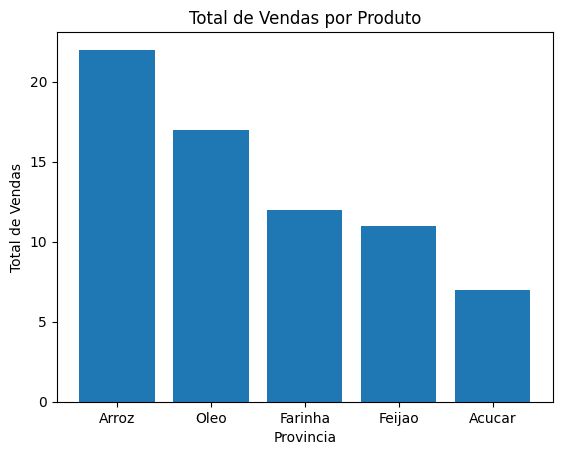

In [31]:
import matplotlib.pyplot as plt


# Criar gráfico de barras
plt.figure()
plt.bar(resumo.index, resumo.values)

# Títulos
plt.title("Total de Vendas por Produto")
plt.xlabel("Provincia")
plt.ylabel("Total de Vendas")

# Mostrar gráfico
plt.show()

In [ ]:
plt.figure()

plt.bar(df["Produto"], df["Estoque_Atual"], label="Estoque Atual")
plt.bar(df["Produto"], df["Estoque_Ideal"], alpha=0.6, label="Estoque Ideal")

plt.title("Comparação: Estoque Atual vs Ideal")
plt.xlabel("Produto")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("Outputs/grafico.png")
plt.close()

In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

doc = SimpleDocTemplate("Outputs/Relatorio_Analise_Estoque.pdf")
elements = []
styles = getSampleStyleSheet()

elements.append(Paragraph("RELATÓRIO DE ANÁLISE DE ESTOQUE", styles["Heading1"]))
elements.append(Spacer(1, 20))

elements.append(Paragraph(f"Total de Vendas: {total_vendas}", styles["Normal"]))
elements.append(Paragraph(f"Média de Vendas Diárias: {media_vendas}", styles["Normal"]))
elements.append(Paragraph(f"Produtos Críticos: {produtos_criticos}", styles["Normal"]))

elements.append(Spacer(1, 30))

elements.append(Paragraph("Gráfico: Estoque Atual vs Ideal", styles["Heading2"]))
elements.append(Spacer(1, 20))

elements.append(Image("grafico.png", width=5*inch, height=3*inch))

doc.build(elements)
print("PDF gerado com sucesso!")

PDF gerado com sucesso!
